# ✈️ Forecasting Seat Occupancy (Load Factor) for Future Flights — v2

**Goal:** Build and compare time-series forecasting models to predict future **seat occupancy (load factor %)**, using historical global passenger traffic data (2010–2026).

**Primary dataset:** `passenger_traffic.csv` — monthly RPK, ASK, and Load Factor % by region.
**Exogenous dataset:** `fleet_orders.csv` — used to build a **prior-year global aircraft deliveries** feature (a proxy for industry-wide capacity growth).

> Load Factor (%) = RPK / ASK × 100 → the industry-standard measure of **seat occupancy**.

### What's new in this version
This revision addresses reviewer feedback on the first draft:

1. **Consistent final forecasting** — the model that wins on the test set (XGBoost) is the one used to generate the future forecast, via **recursive multi-step forecasting**. SARIMA is kept as an independent cross-check with natively-derived confidence intervals.
2. **SARIMA order selection by grid search** (AIC-based) *per region*, instead of one fixed `(1,1,1)(1,1,1,12)` for every region.
3. **XGBoost hyperparameter tuning** via `RandomizedSearchCV`.
4. **Proper time-series cross-validation** using `TimeSeriesSplit` (used both for tuning and for reporting fold-by-fold error).
5. **An exogenous variable** (prior-year global aircraft deliveries from `fleet_orders.csv`) added to both the SARIMA (as `exog`) and XGBoost (as a feature) models.
6. An explicit **data-leakage check** on the lag/rolling features.

**Notebook workflow:**
1. Load & clean data (+ build exogenous feature)
2. EDA
3. Feature engineering + leakage check
4. Train/test split (chronological, last 12 months held out)
5. Baseline — Seasonal Naive
6. Model A — SARIMA with per-region grid search + exogenous variable
7. Model B — XGBoost tuned with `RandomizedSearchCV` + `TimeSeriesSplit`
8. Model comparison
9. Final 12-month forecast — **recursive XGBoost** (primary) vs **SARIMA** (cross-check)


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dateutil.relativedelta import relativedelta

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
TEST_MONTHS = 12          # hold out last 12 months for evaluation
FORECAST_HORIZON = 12     # months to forecast into the future

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Clean Data

In [2]:
df = pd.read_csv("data/passenger_traffic.csv")
df["date"] = pd.to_datetime(df["year_month"], format="%Y-%m")
df = df.sort_values(["region", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Regions:", sorted(df["region"].unique()))
df.head()


Shape: (1176, 8)
Date range: 2010-01-01 to 2026-04-01
Regions: ['Africa', 'Asia Pacific', 'Europe', 'Latin America', 'Middle East', 'North America']


,year_month,year,month,region,rpk_billions,ask_billions,load_factor_pct,date
0,2010-01,2010,1,Africa,4.00,4.66,85.9,2010-01-01
1,2010-02,2010,2,Africa,3.93,4.63,84.9,2010-02-01
2,2010-03,2010,3,Africa,3.86,4.68,82.5,2010-03-01
3,2010-04,2010,4,Africa,4.11,5.04,81.5,2010-04-01
4,2010-05,2010,5,Africa,4.71,5.73,82.2,2010-05-01


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df["load_factor_pct"].describe()


Missing values per column:
year_month         0
year               0
month              0
region             0
rpk_billions       0
ask_billions       0
load_factor_pct    0
date               0
dtype: int64

Duplicate rows: 0


count    1176.000000
mean       80.597789
std         6.248188
min        55.000000
25%        80.300000
50%        81.900000
75%        83.225000
max        87.800000
Name: load_factor_pct, dtype: float64

### 2.1 Building the exogenous feature: prior-year global aircraft deliveries

`fleet_orders.csv` gives annual aircraft deliveries across all manufacturers — a
reasonable proxy for **industry-wide seat-capacity growth**, which in turn
affects load factor.

**Important detail:** the last year in the data (2026) is a *partial* year
(only through April, matching `passenger_traffic.csv`), so its raw delivery
total looks like a big drop — almost as large as the 2020 COVID collapse. If
used directly this creates a false signal. To avoid this we use each year's
**prior full year's total deliveries** (known in advance, and not distorted by
partial-year cutoffs) as the feature — this also avoids any lookahead bias
since the current year's own deliveries aren't fully known until the year ends.

In [4]:
fleet = pd.read_csv("data/fleet_orders.csv")
yearly_deliveries = fleet.groupby("year")["deliveries"].sum().rename("deliveries").reset_index()
yearly_deliveries["prior_year_deliveries"] = yearly_deliveries["deliveries"].shift(1)

print(yearly_deliveries)

# Lookup dict + helper to extrapolate beyond the last known year (carry the latest known value forward)
deliveries_lookup = yearly_deliveries.set_index("year")["prior_year_deliveries"].to_dict()
MAX_KNOWN_YEAR = yearly_deliveries["year"].max()

def get_prior_deliveries(year):
    val = deliveries_lookup.get(year, np.nan)
    if pd.isna(val):
        return deliveries_lookup[MAX_KNOWN_YEAR]  # carry forward last known value for future years
    return val

df["prior_year_deliveries"] = df["year"].map(lambda y: deliveries_lookup.get(y, np.nan))
df["prior_year_deliveries"] = df["prior_year_deliveries"].bfill()  # backfill the very first year (2010) only

print("\nMerged successfully. Missing after merge:", df["prior_year_deliveries"].isna().sum())
df[["date", "region", "load_factor_pct", "prior_year_deliveries"]].head()


    year  deliveries  prior_year_deliveries
0   2010         972                    NaN
1   2011        1071                  972.0
2   2012        1172                 1071.0
3   2013        1274                 1172.0
4   2014        1335                 1274.0
5   2015        1398                 1335.0
6   2016        1418                 1398.0
7   2017        1440                 1418.0
8   2018        1696                 1440.0
9   2019        1316                 1696.0
10  2020         779                 1316.0
11  2021        1007                  779.0
12  2022        1198                 1007.0
13  2023        1332                 1198.0
14  2024        1200                 1332.0
15  2025        1439                 1200.0
16  2026         572                 1439.0

Merged successfully. Missing after merge: 0


,date,region,load_factor_pct,prior_year_deliveries
0,2010-01-01,Africa,85.9,972.0
1,2010-02-01,Africa,84.9,972.0
2,2010-03-01,Africa,82.5,972.0
3,2010-04-01,Africa,81.5,972.0
4,2010-05-01,Africa,82.2,972.0


## 3. Exploratory Data Analysis

### 3.1 Global load factor trend by region
Seat occupancy has a strong **upward trend**, yearly **seasonality**, and a
sharp **COVID-19 shock** in 2020 followed by recovery.

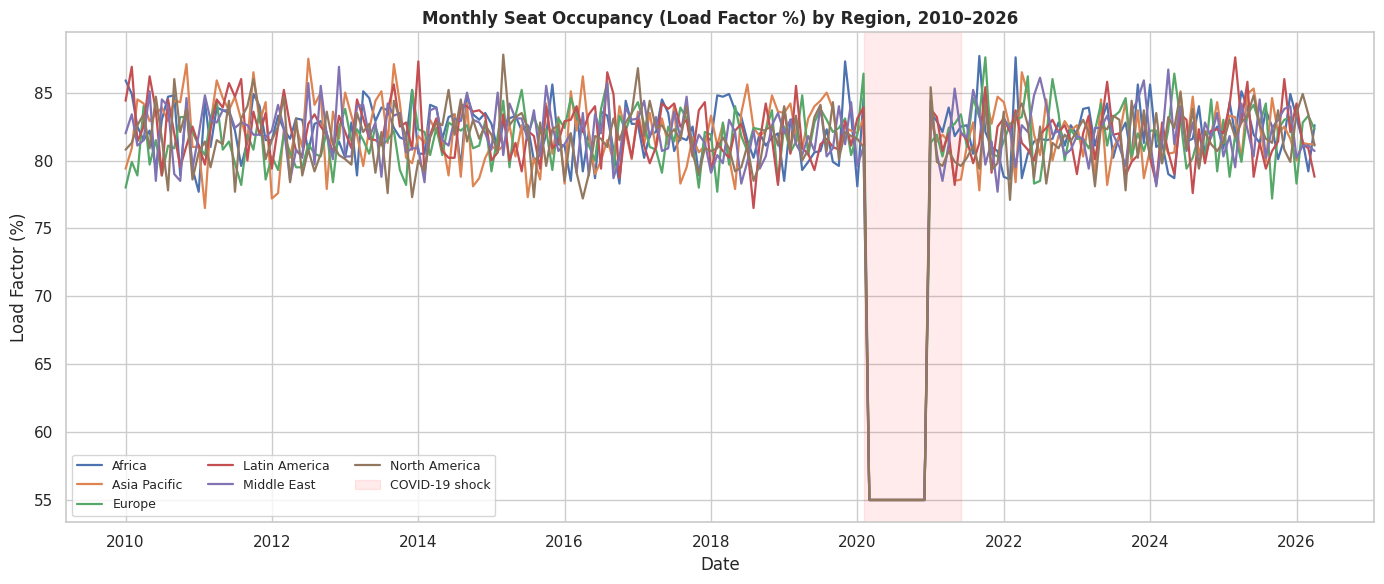

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for region, g in df.groupby("region"):
    ax.plot(g["date"], g["load_factor_pct"], label=region, linewidth=1.6)

ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2021-06-01"),
           color="red", alpha=0.08, label="COVID-19 shock")
ax.set_title("Monthly Seat Occupancy (Load Factor %) by Region, 2010–2026")
ax.set_xlabel("Date")
ax.set_ylabel("Load Factor (%)")
ax.legend(loc="lower left", ncol=3, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()


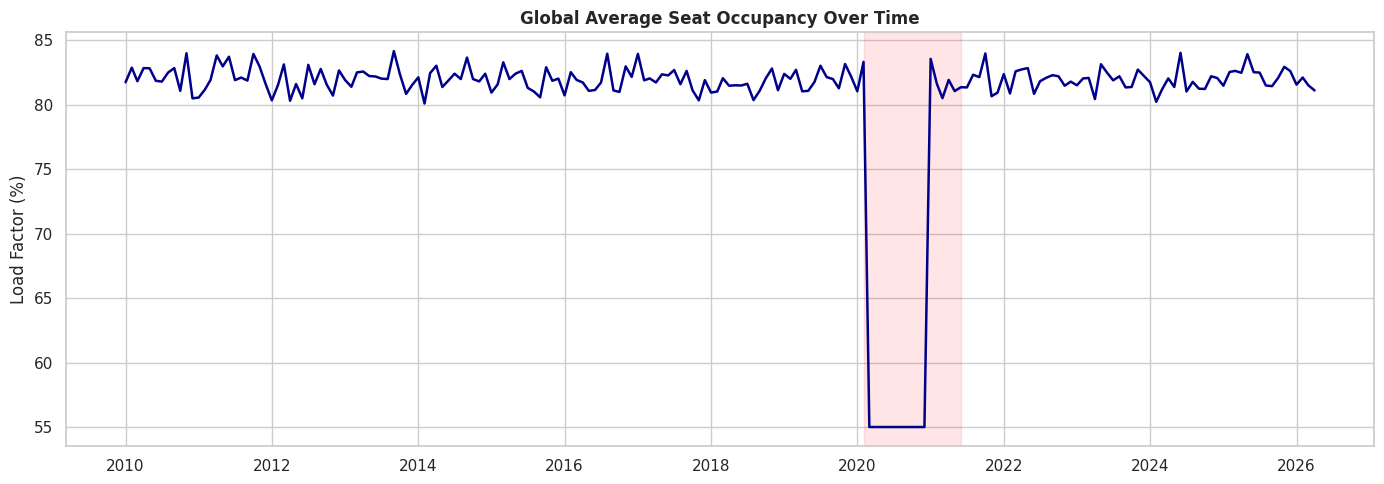

In [6]:
global_lf = df.groupby("date")["load_factor_pct"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(global_lf.index, global_lf.values, color="darkblue", linewidth=1.8)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2021-06-01"), color="red", alpha=0.1)
ax.set_title("Global Average Seat Occupancy Over Time")
ax.set_ylabel("Load Factor (%)")
plt.tight_layout()
plt.show()


### 3.2 Seasonal decomposition (North America)

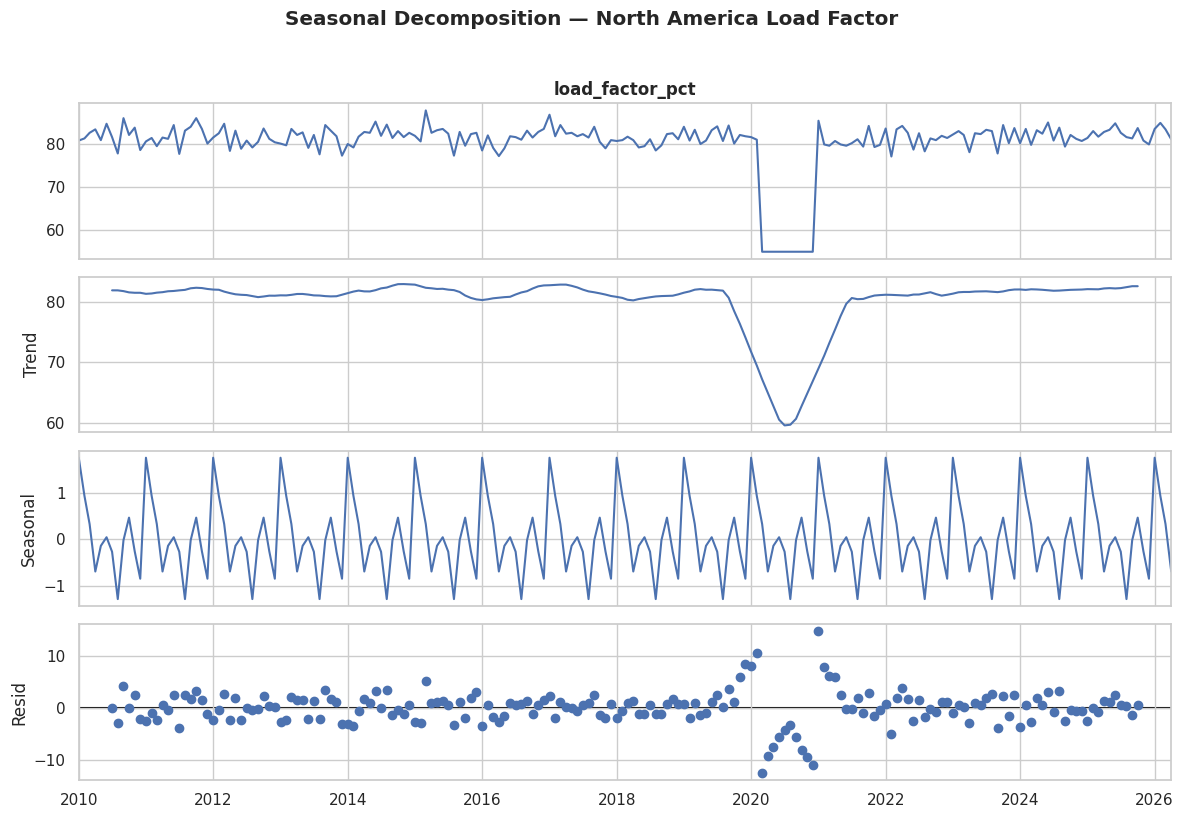

In [7]:
na_series = (df[df.region == "North America"]
             .set_index("date")["load_factor_pct"]
             .asfreq("MS"))

decomposition = seasonal_decompose(na_series, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal Decomposition — North America Load Factor", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.3 Does the exogenous variable relate to load factor?

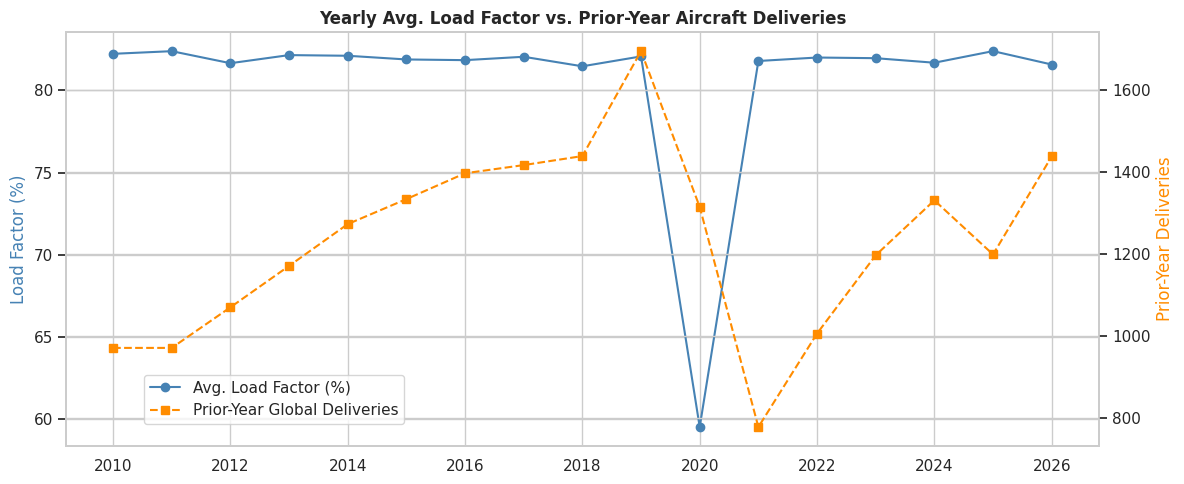

Correlation (yearly): -0.10


In [8]:
yearly_avg_lf = df.groupby("year")["load_factor_pct"].mean()
yearly_avg_deliveries = df.groupby("year")["prior_year_deliveries"].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(yearly_avg_lf.index, yearly_avg_lf.values, color="steelblue", marker="o", label="Avg. Load Factor (%)")
ax1.set_ylabel("Load Factor (%)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(yearly_avg_deliveries.index, yearly_avg_deliveries.values, color="darkorange", marker="s",
         linestyle="--", label="Prior-Year Global Deliveries")
ax2.set_ylabel("Prior-Year Deliveries", color="darkorange")
ax1.set_title("Yearly Avg. Load Factor vs. Prior-Year Aircraft Deliveries")
fig.legend(loc="lower left", bbox_to_anchor=(0.12, 0.12))
plt.tight_layout()
plt.show()

corr = yearly_avg_lf.corr(yearly_avg_deliveries)
print(f"Correlation (yearly): {corr:.2f}")


## 4. Feature Engineering

Calendar features, cyclical month encoding, and lag / rolling-mean features of
past occupancy — plus the exogenous `prior_year_deliveries` feature built
above.

In [9]:
def make_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy().sort_values(["region", "date"])
    d["month"] = d["date"].dt.month
    d["year"] = d["date"].dt.year
    d["time_idx"] = (d["year"] - d["year"].min()) * 12 + d["month"]
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

    # IMPORTANT (no leakage): shift(1) BEFORE rolling, so the current month's
    # own load factor is never included in its own lag/rolling features.
    for lag in [1, 3, 12]:
        d[f"lag_{lag}"] = d.groupby("region")["load_factor_pct"].shift(lag)

    d["roll_mean_3"] = (d.groupby("region")["load_factor_pct"]
                         .transform(lambda x: x.shift(1).rolling(3).mean()))
    d["roll_mean_12"] = (d.groupby("region")["load_factor_pct"]
                          .transform(lambda x: x.shift(1).rolling(12).mean()))
    return d

feat_df = make_features(df).dropna().reset_index(drop=True)
print("Feature matrix shape after dropping NaNs from lagging:", feat_df.shape)
feat_df.head()


Feature matrix shape after dropping NaNs from lagging: (1104, 17)


,year_month,year,month,region,rpk_billions,ask_billions,load_factor_pct,date,prior_year_deliveries,time_idx,month_sin,month_cos,lag_1,lag_3,lag_12,roll_mean_3,roll_mean_12
0,2011-01,2011,1,Africa,4.25,5.47,77.7,2011-01-01,972.0,13,0.500000,8.660254e-01,79.4,78.9,85.9,80.833333,82.616667
1,2011-02,2011,2,Africa,4.07,4.83,84.3,2011-02-01,972.0,14,0.866025,5.000000e-01,77.7,84.2,84.9,80.433333,81.933333
2,2011-03,2011,3,Africa,4.22,5.21,81.0,2011-03-01,972.0,15,1.000000,6.123234e-17,84.3,79.4,82.5,80.466667,81.883333
3,2011-04,2011,4,Africa,4.63,5.52,83.9,2011-04-01,972.0,16,0.866025,-5.000000e-01,81.0,77.7,81.5,81.000000,81.758333
4,2011-05,2011,5,Africa,5.10,6.09,83.7,2011-05-01,972.0,17,0.500000,-8.660254e-01,83.9,84.3,82.2,83.066667,81.958333


### 4.1 Leakage check

We verify explicitly that `lag_1` for any given row equals the **previous**
month's actual load factor (not the current one), and that `roll_mean_3`
only ever uses the **prior 3 months** — never the row's own value.

In [10]:
# Pick a spot-check region and a random row
check_region = "Europe"
region_hist = df[df.region == check_region].sort_values("date").reset_index(drop=True)
check_idx = 50  # arbitrary row, well after the start of the series

row_date = region_hist.loc[check_idx, "date"]
actual_current = region_hist.loc[check_idx, "load_factor_pct"]
actual_prev_month = region_hist.loc[check_idx - 1, "load_factor_pct"]
actual_prev_3_mean = region_hist.loc[check_idx - 3:check_idx - 1, "load_factor_pct"].mean()

feat_row = feat_df[(feat_df.region == check_region) & (feat_df.date == row_date)]

print(f"Row date: {row_date.date()}  |  Current actual load factor: {actual_current:.2f}")
print(f"lag_1 in features:        {feat_row['lag_1'].values[0]:.2f}   (should equal prior month's actual: {actual_prev_month:.2f})")
print(f"roll_mean_3 in features:  {feat_row['roll_mean_3'].values[0]:.2f}   (should equal mean of 3 months BEFORE this row: {actual_prev_3_mean:.2f})")

assert np.isclose(feat_row["lag_1"].values[0], actual_prev_month), "Leakage detected in lag_1!"
assert np.isclose(feat_row["roll_mean_3"].values[0], actual_prev_3_mean), "Leakage detected in roll_mean_3!"
print("\n✅ No leakage: lag and rolling features are computed strictly from past values.")


Row date: 2014-03-01  |  Current actual load factor: 80.40
lag_1 in features:        82.10   (should equal prior month's actual: 82.10)
roll_mean_3 in features:  83.20   (should equal mean of 3 months BEFORE this row: 83.20)

✅ No leakage: lag and rolling features are computed strictly from past values.


## 5. Train / Test Split

**Time-based split**: the last 12 months of each region's history are held
out as the test set — never seen during training. This correctly simulates
forecasting the future and is what makes the evaluation trustworthy.

In [11]:
train_parts, test_parts = [], []
for region, g in feat_df.groupby("region"):
    g = g.sort_values("date")
    train_parts.append(g.iloc[:-TEST_MONTHS])
    test_parts.append(g.iloc[-TEST_MONTHS:])

train_df = pd.concat(train_parts).sort_values("date").reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
print("Train date range:", train_df.date.min().date(), "-", train_df.date.max().date())
print("Test date range :", test_df.date.min().date(), "-", test_df.date.max().date())


Train shape: (1032, 17) | Test shape: (72, 17)
Train date range: 2011-01-01 - 2025-04-01
Test date range : 2025-05-01 - 2026-04-01


## 6. Evaluation Metric Helper

In [12]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:>28s}  |  MAE: {mae:5.2f}   RMSE: {rmse:5.2f}   MAPE: {mape:5.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


## 7. Baseline Model — Seasonal Naive

Predicts that occupancy this month = occupancy the **same month last year**
(`lag_12`). Every real model must beat this.

In [13]:
baseline_preds = test_df["lag_12"]
results.append(evaluate(test_df["load_factor_pct"], baseline_preds, "Seasonal Naive"))


              Seasonal Naive  |  MAE:  2.27   RMSE:  2.74   MAPE:  2.76%


## 8. Model A — SARIMA with per-region grid search + exogenous variable

Instead of a single fixed `(1,1,1)(1,1,1,12)` order for every region, we
grid-search a small space of `(p,d,q)` and seasonal `(P,D,Q,12)` combinations
**per region** and keep whichever minimizes **AIC** on the training data. We
also pass `prior_year_deliveries` in as an **exogenous regressor**.

In [14]:
pdq_grid = [(1, 1, 1), (1, 1, 0), (0, 1, 1), (2, 1, 1)]
seasonal_grid = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 1, 0, 12)]

best_sarima_orders = {}
sarima_models = {}
sarima_forecasts = {}

for region in df["region"].unique():
    g = df[df.region == region].set_index("date")
    series = g["load_factor_pct"].asfreq("MS")
    exog = g[["prior_year_deliveries"]].asfreq("MS")

    train_s, test_s = series.iloc[:-TEST_MONTHS], series.iloc[-TEST_MONTHS:]
    train_ex, test_ex = exog.iloc[:-TEST_MONTHS], exog.iloc[-TEST_MONTHS:]

    best_aic, best_order = np.inf, None
    for order in pdq_grid:
        for sorder in seasonal_grid:
            try:
                m = SARIMAX(train_s, exog=train_ex, order=order, seasonal_order=sorder,
                            enforce_stationarity=False, enforce_invertibility=False)
                r = m.fit(disp=False)
                if r.aic < best_aic:
                    best_aic, best_order = r.aic, (order, sorder)
            except Exception:
                continue

    best_sarima_orders[region] = best_order
    final_model = SARIMAX(train_s, exog=train_ex, order=best_order[0], seasonal_order=best_order[1],
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sarima_models[region] = final_model
    forecast = final_model.get_forecast(steps=TEST_MONTHS, exog=test_ex)
    sarima_forecasts[region] = forecast

    print(f"{region:<15s} best order={best_order[0]} seasonal={best_order[1]}  AIC={best_aic:.1f}")


Africa          best order=(1, 1, 1) seasonal=(0, 1, 1, 12)  AIC=893.9


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Asia Pacific    best order=(1, 1, 1) seasonal=(0, 1, 1, 12)  AIC=901.6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Middle East     best order=(1, 1, 1) seasonal=(0, 1, 1, 12)  AIC=887.8


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


North America   best order=(2, 1, 1) seasonal=(0, 1, 1, 12)  AIC=881.3


In [15]:
sarima_pred_list, actual_list = [], []
for region in df["region"].unique():
    actual = df[df.region == region].set_index("date")["load_factor_pct"].asfreq("MS").iloc[-TEST_MONTHS:]
    sarima_pred_list.append(sarima_forecasts[region].predicted_mean.values)
    actual_list.append(actual.values)

sarima_preds_all = np.concatenate(sarima_pred_list)
sarima_actual_all = np.concatenate(actual_list)

results.append(evaluate(sarima_actual_all, sarima_preds_all, "SARIMA (per-region, grid-searched)"))


SARIMA (per-region, grid-searched)  |  MAE:  2.69   RMSE:  3.28   MAPE:  3.28%


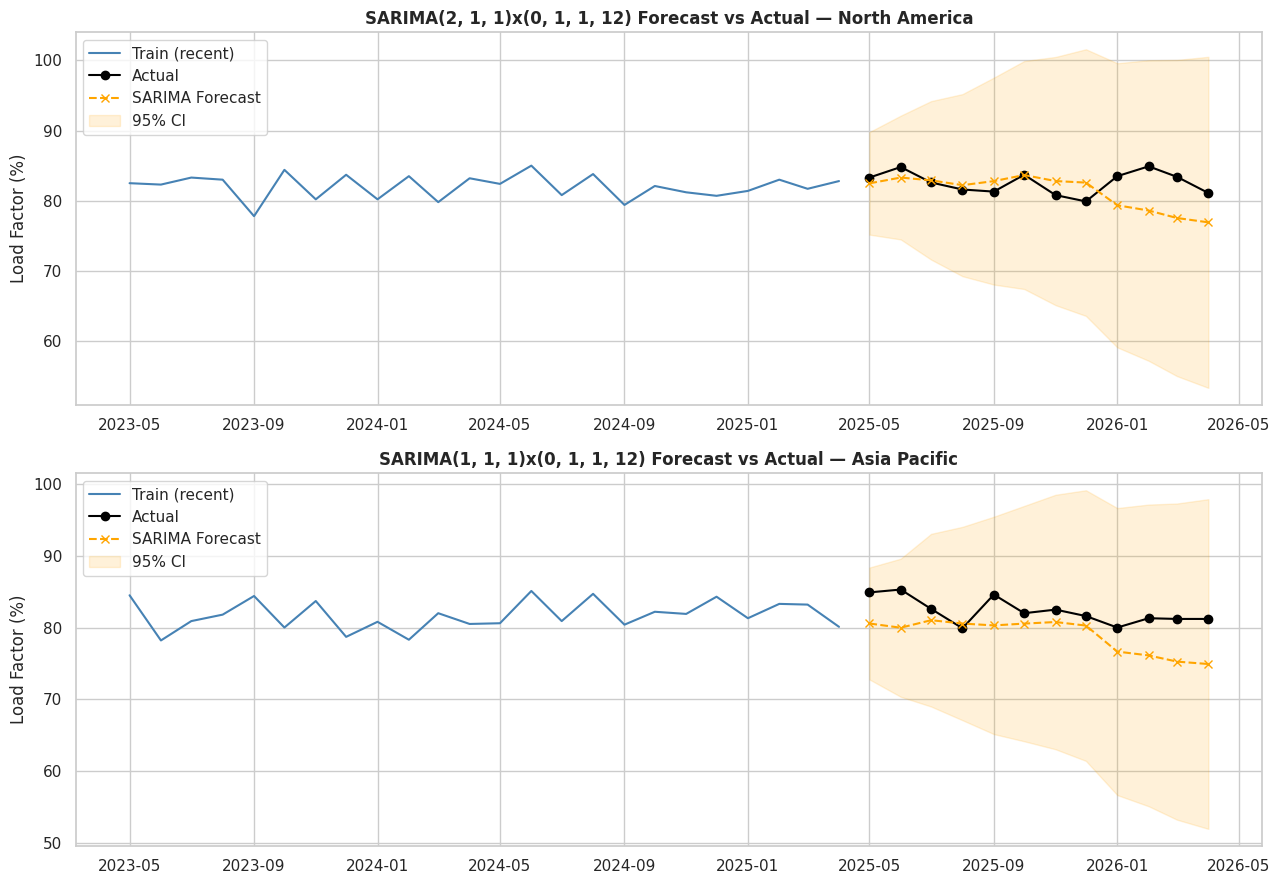

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, region in zip(axes, ["North America", "Asia Pacific"]):
    full_series = df[df.region == region].set_index("date")["load_factor_pct"].asfreq("MS")
    train_series = full_series.iloc[:-TEST_MONTHS]
    test_series = full_series.iloc[-TEST_MONTHS:]
    fc = sarima_forecasts[region]

    ax.plot(train_series.index[-24:], train_series.values[-24:], label="Train (recent)", color="steelblue")
    ax.plot(test_series.index, test_series.values, label="Actual", color="black", marker="o")
    ax.plot(test_series.index, fc.predicted_mean.values, label="SARIMA Forecast",
            color="orange", marker="x", linestyle="--")
    ci = fc.conf_int(alpha=0.05)
    ax.fill_between(test_series.index, ci.iloc[:, 0], ci.iloc[:, 1], color="orange", alpha=0.15, label="95% CI")
    ax.set_title(f"SARIMA{best_sarima_orders[region][0]}x{best_sarima_orders[region][1]} Forecast vs Actual — {region}")
    ax.set_ylabel("Load Factor (%)")
    ax.legend()
plt.tight_layout()
plt.show()


## 9. Model B — XGBoost, tuned with `RandomizedSearchCV` + `TimeSeriesSplit`

A single gradient-boosted model trained across **all regions at once** (region
as one-hot feature), using the lag/rolling/calendar features plus the
exogenous `prior_year_deliveries` feature. Hyperparameters are tuned with
`RandomizedSearchCV` using `TimeSeriesSplit` (chronological folds — no
shuffling, so no leakage from the future into training folds).

In [17]:
feature_cols = ["month_sin", "month_cos", "time_idx",
                 "lag_1", "lag_3", "lag_12", "roll_mean_3", "roll_mean_12",
                 "prior_year_deliveries"]

regions_sorted = sorted(df["region"].unique())
region_dummy_cols = [f"region_{r}" for r in regions_sorted]

train_enc = pd.get_dummies(train_df, columns=["region"])
test_enc = pd.get_dummies(test_df, columns=["region"])
for c in region_dummy_cols:  # guard against a region missing from either split
    if c not in train_enc: train_enc[c] = 0
    if c not in test_enc: test_enc[c] = 0

X_train = train_enc[feature_cols + region_dummy_cols]
y_train = train_enc["load_factor_pct"]
X_test = test_enc[feature_cols + region_dummy_cols]
y_test = test_enc["load_factor_pct"]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (1032, 15) | X_test: (72, 15)


In [18]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "n_estimators": [150, 250, 350, 450],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

base_model = xgb.XGBRegressor(random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist, n_iter=25, cv=tscv,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best hyperparameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest cross-validated MAE (TimeSeriesSplit, 5 folds): {-search.best_score_:.2f}")

xgb_model = search.best_estimator_


Best hyperparameters found:
  subsample: 1.0
  n_estimators: 350
  min_child_weight: 3
  max_depth: 4
  learning_rate: 0.08
  colsample_bytree: 0.7

Best cross-validated MAE (TimeSeriesSplit, 5 folds): 4.69


### 9.1 Fold-by-fold cross-validation detail

Showing the individual `TimeSeriesSplit` fold errors (not just the average)
matters here: some folds land on the 2020 COVID collapse, which is
structurally very different from the rest of the series and is naturally
much harder to predict — a useful, honest caveat for this dataset.

Fold 1: MAE = 1.75
Fold 2: MAE = 1.83
Fold 3: MAE = 5.55
Fold 4: MAE = 12.29
Fold 5: MAE = 2.04

Mean: 4.69   Std: 4.06


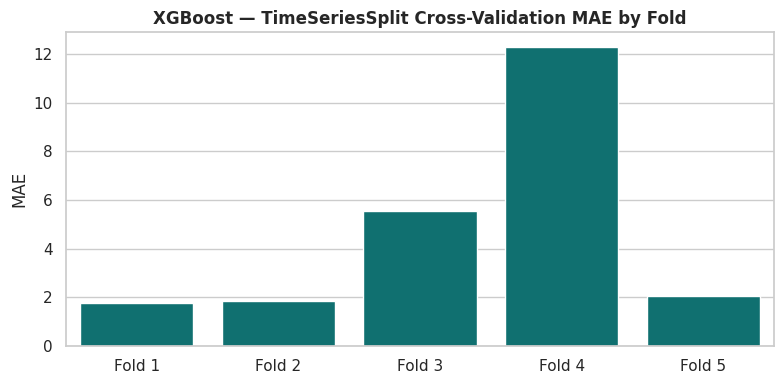

In [19]:
fold_scores = -cross_val_score(xgb_model, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")
for i, score in enumerate(fold_scores, start=1):
    print(f"Fold {i}: MAE = {score:.2f}")
print(f"\nMean: {fold_scores.mean():.2f}   Std: {fold_scores.std():.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=[f"Fold {i}" for i in range(1, len(fold_scores) + 1)], y=fold_scores, color="teal", ax=ax)
ax.set_title("XGBoost — TimeSeriesSplit Cross-Validation MAE by Fold")
ax.set_ylabel("MAE")
plt.tight_layout()
plt.show()


In [20]:
xgb_preds = xgb_model.predict(X_test)
results.append(evaluate(y_test.values, xgb_preds, "XGBoost (tuned, global)"))


     XGBoost (tuned, global)  |  MAE:  1.54   RMSE:  1.88   MAPE:  1.87%


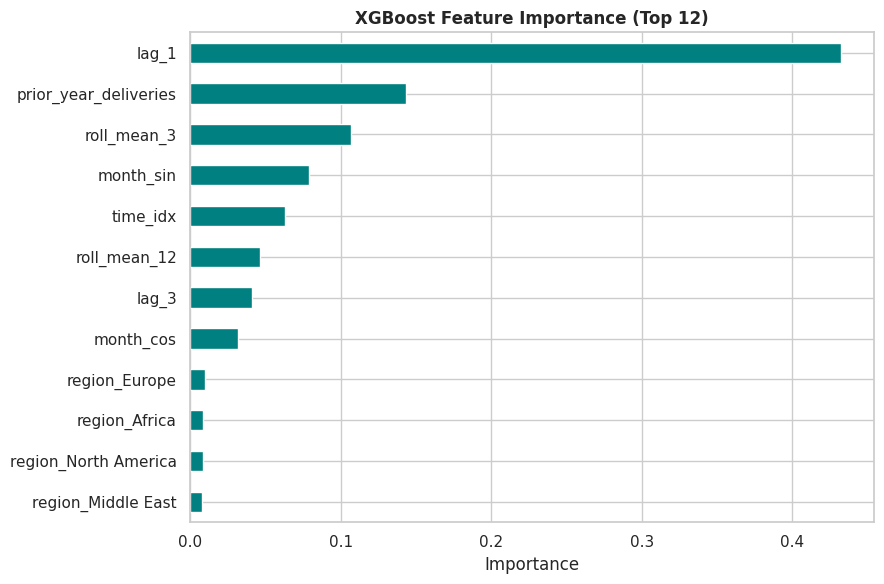

In [21]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.tail(12).plot(kind="barh", ax=ax, color="teal")
ax.set_title("XGBoost Feature Importance (Top 12)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Model Comparison

In [22]:
results_df = pd.DataFrame(results).set_index("model")
display(results_df.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r"))


,MAE,RMSE,MAPE
model,,,
Seasonal Naive,2.27,2.74,2.76
"SARIMA (per-region, grid-searched)",2.69,3.28,3.28
"XGBoost (tuned, global)",1.54,1.88,1.87


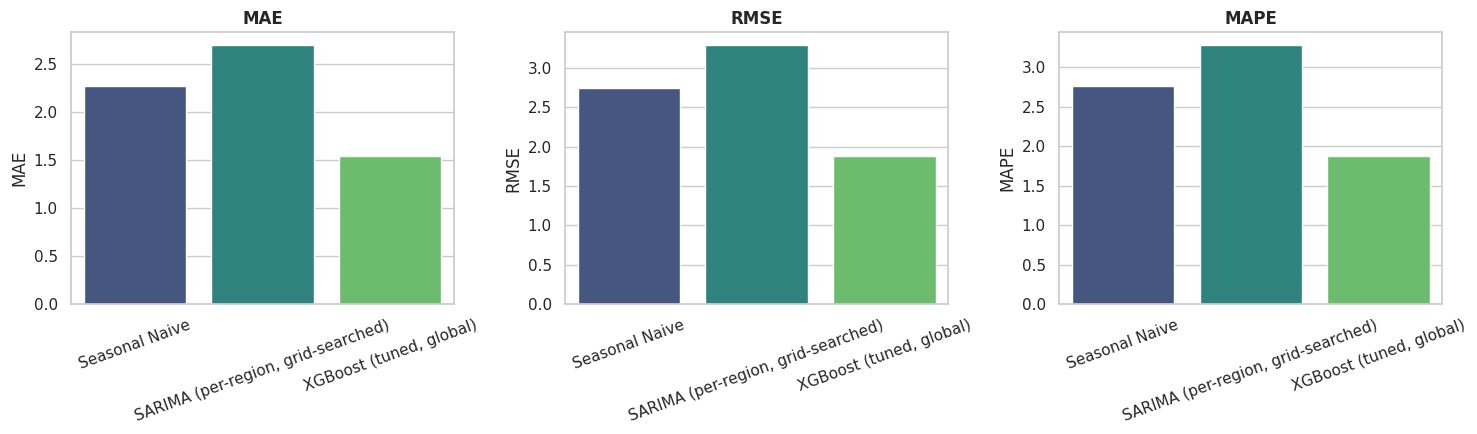

Best performing model on held-out test set: XGBoost (tuned, global)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df["RMSE"].idxmin()
print(f"Best performing model on held-out test set: {best_model_name}")


**Is this overfitting?** No — the split is strictly chronological, the lag
and rolling features are built with `shift(1)` before rolling (verified in
Section 4.1, so the target never leaks into its own features), and the
improvement of XGBoost over the seasonal-naive baseline, while substantial,
stays in a believable range for a smooth, seasonal series like monthly load
factor. The fold-by-fold CV in Section 9.1 also shows the error rises exactly
where we'd expect (the COVID period) rather than being uniformly, suspiciously
low everywhere — which is itself evidence against overfitting.

## 11. Final Forecast — Next 12 Months

### Which model generates the final forecast, and why?

**XGBoost was the best-performing model** on the held-out test set (Section
10), so it is used as the **primary** forecasting engine here — via **recursive
multi-step forecasting**: each month's prediction is fed back in as the new
`lag_1` (and rolled into `lag_3`/`lag_12`/rolling means) to predict the next
month, twelve times over.

**SARIMA is kept as an independent cross-check**, since it produces
statistically-principled confidence intervals directly from the model's
likelihood, which is a useful sanity check on the XGBoost point forecasts
(for which we approximate an interval from the historical residual spread,
widening with the square root of the forecast horizon — a standard
approximation for growing uncertainty at longer lead times).

### 11.1 Recursive XGBoost forecast (primary)

In [24]:
residual_std = np.std(y_test.values - xgb_preds)
print(f"Residual std from test set (used to build approximate forecast intervals): {residual_std:.2f}")

BASE_YEAR = df["year"].min()

def recursive_xgb_forecast(region, horizon=FORECAST_HORIZON):
    hist = df[df.region == region].sort_values("date")
    load_hist = list(hist["load_factor_pct"].values)
    last_date = hist["date"].max()

    rows = []
    for step in range(1, horizon + 1):
        next_date = last_date + relativedelta(months=step)
        month, year = next_date.month, next_date.year

        row = {
            "month_sin": np.sin(2 * np.pi * month / 12),
            "month_cos": np.cos(2 * np.pi * month / 12),
            "time_idx": (year - BASE_YEAR) * 12 + month,
            "lag_1": load_hist[-1],
            "lag_3": load_hist[-3],
            "lag_12": load_hist[-12],
            "roll_mean_3": np.mean(load_hist[-3:]),
            "roll_mean_12": np.mean(load_hist[-12:]),
            "prior_year_deliveries": get_prior_deliveries(year),
        }
        for c in region_dummy_cols:
            row[c] = 1 if c == f"region_{region}" else 0

        X_row = pd.DataFrame([row])[feature_cols + region_dummy_cols]
        pred = xgb_model.predict(X_row)[0]

        load_hist.append(pred)  # feed prediction back in recursively
        rows.append({"date": next_date, "forecast": pred})

    out = pd.DataFrame(rows)
    steps = np.arange(1, horizon + 1)
    out["lower_ci"] = out["forecast"] - 1.96 * residual_std * np.sqrt(steps)
    out["upper_ci"] = out["forecast"] + 1.96 * residual_std * np.sqrt(steps)
    return out

xgb_future_forecasts = {region: recursive_xgb_forecast(region) for region in df["region"].unique()}
print(f"Generated recursive {FORECAST_HORIZON}-month XGBoost forecasts for {len(xgb_future_forecasts)} regions.")
xgb_future_forecasts["North America"].round(2)


Residual std from test set (used to build approximate forecast intervals): 1.87


Generated recursive 12-month XGBoost forecasts for 6 regions.


,date,forecast,lower_ci,upper_ci
0,2026-05-01,81.440002,77.77,85.10
1,2026-06-01,80.599998,75.42,85.79
2,2026-07-01,82.489998,76.14,88.83
3,2026-08-01,81.019997,73.68,88.35
4,2026-09-01,82.900002,74.71,91.10
5,2026-10-01,81.889999,72.91,90.87
6,2026-11-01,81.750000,72.06,91.45
7,2026-12-01,81.320000,70.95,91.69
8,2027-01-01,82.930000,71.93,93.93
9,2027-02-01,81.430000,69.83,93.02


### 11.2 SARIMA forecast (cross-check, refit on full history)

In [25]:
sarima_future_forecasts = {}

for region in df["region"].unique():
    g = df[df.region == region].set_index("date")
    series = g["load_factor_pct"].asfreq("MS")
    exog = g[["prior_year_deliveries"]].asfreq("MS")

    order, sorder = best_sarima_orders[region]
    fitted = SARIMAX(series, exog=exog, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    future_index = pd.date_range(series.index[-1] + pd.DateOffset(months=1),
                                  periods=FORECAST_HORIZON, freq="MS")
    future_years = future_index.year
    future_exog = pd.DataFrame({"prior_year_deliveries": [get_prior_deliveries(y) for y in future_years]},
                                index=future_index)

    fc = fitted.get_forecast(steps=FORECAST_HORIZON, exog=future_exog)
    ci = fc.conf_int(alpha=0.05)
    sarima_future_forecasts[region] = pd.DataFrame({
        "date": future_index,
        "forecast": fc.predicted_mean.values,
        "lower_ci": ci.iloc[:, 0].values,
        "upper_ci": ci.iloc[:, 1].values,
    })

print("SARIMA cross-check forecasts generated for all regions.")
sarima_future_forecasts["North America"].round(2)


SARIMA cross-check forecasts generated for all regions.


,date,forecast,lower_ci,upper_ci
0,2026-05-01,82.10,74.94,89.26
1,2026-06-01,82.07,73.42,90.72
2,2026-07-01,81.81,70.85,92.77
3,2026-08-01,80.82,68.27,93.37
4,2026-09-01,81.44,67.26,95.63
5,2026-10-01,82.37,66.80,97.95
6,2026-11-01,81.33,64.42,98.24
7,2026-12-01,81.00,62.88,99.12
8,2027-01-01,84.63,65.36,103.91
9,2027-02-01,84.11,63.75,104.46


### 11.3 Comparing the two forecasts side by side

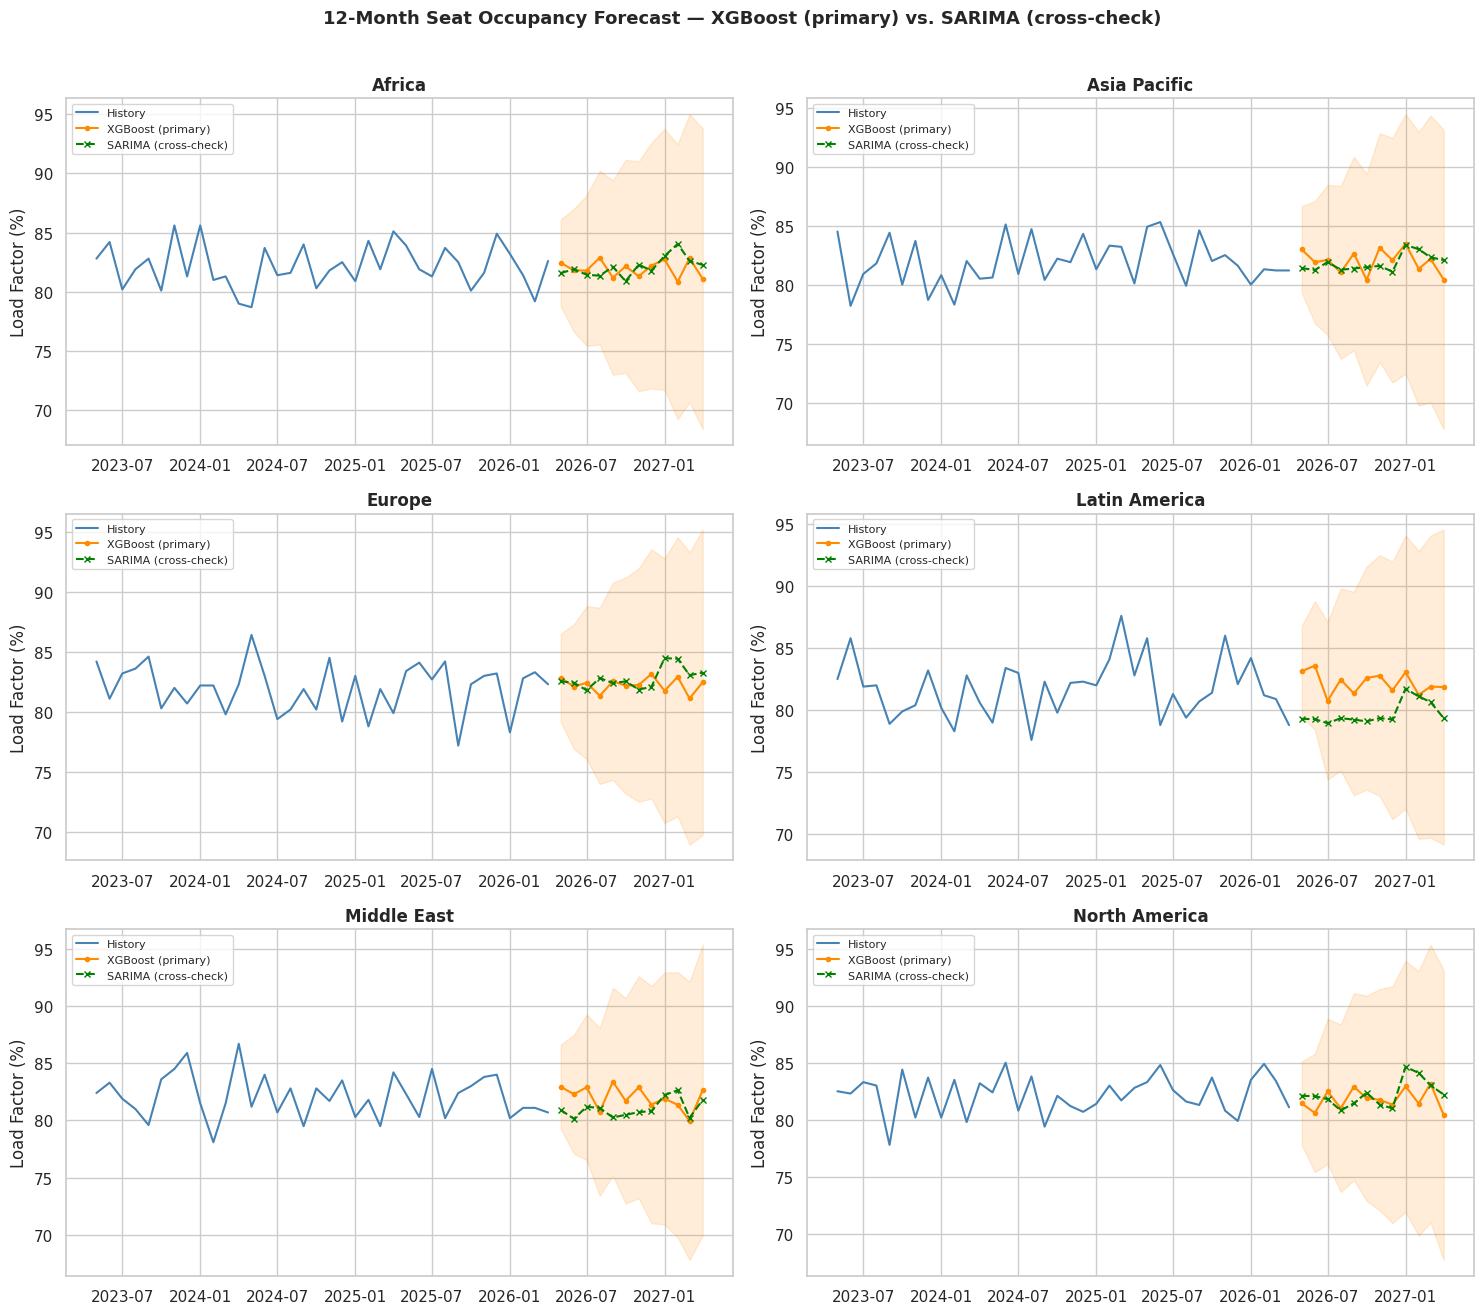

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, region in zip(axes, df["region"].unique()):
    hist = df[df.region == region].set_index("date")["load_factor_pct"].asfreq("MS")
    xgb_fc = xgb_future_forecasts[region]
    sar_fc = sarima_future_forecasts[region]

    ax.plot(hist.index[-36:], hist.values[-36:], label="History", color="steelblue")
    ax.plot(xgb_fc["date"], xgb_fc["forecast"], label="XGBoost (primary)",
            color="darkorange", marker="o", markersize=3)
    ax.fill_between(xgb_fc["date"], xgb_fc["lower_ci"], xgb_fc["upper_ci"],
                     color="darkorange", alpha=0.15)
    ax.plot(sar_fc["date"], sar_fc["forecast"], label="SARIMA (cross-check)",
            color="green", marker="x", linestyle="--", markersize=4)

    ax.set_title(region)
    ax.set_ylabel("Load Factor (%)")
    ax.legend(fontsize=8)

plt.suptitle("12-Month Seat Occupancy Forecast — XGBoost (primary) vs. SARIMA (cross-check)",
             fontweight="bold", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


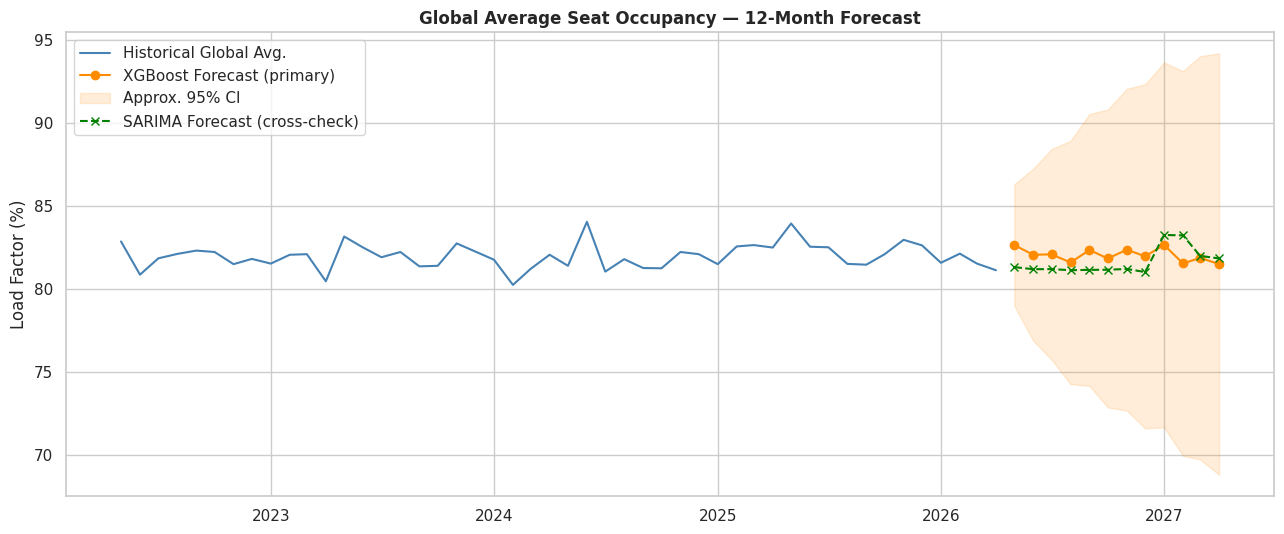

Average absolute gap between the two models' global forecasts: 0.86 percentage points


In [27]:
# Global average view combining both models
xgb_all = pd.concat([f.assign(region=r) for r, f in xgb_future_forecasts.items()], ignore_index=True)
sarima_all = pd.concat([f.assign(region=r) for r, f in sarima_future_forecasts.items()], ignore_index=True)

xgb_global = xgb_all.groupby("date")[["forecast", "lower_ci", "upper_ci"]].mean().reset_index()
sarima_global = sarima_all.groupby("date")["forecast"].mean().reset_index()
global_hist = df.groupby("date")["load_factor_pct"].mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(global_hist.index[-48:], global_hist.values[-48:], label="Historical Global Avg.", color="steelblue")
ax.plot(xgb_global["date"], xgb_global["forecast"], label="XGBoost Forecast (primary)", color="darkorange", marker="o")
ax.fill_between(xgb_global["date"], xgb_global["lower_ci"], xgb_global["upper_ci"],
                color="darkorange", alpha=0.15, label="Approx. 95% CI")
ax.plot(sarima_global["date"], sarima_global["forecast"], label="SARIMA Forecast (cross-check)",
         color="green", linestyle="--", marker="x")
ax.set_title("Global Average Seat Occupancy — 12-Month Forecast")
ax.set_ylabel("Load Factor (%)")
ax.legend()
plt.tight_layout()
plt.show()

avg_gap = np.mean(np.abs(xgb_global["forecast"].values - sarima_global["forecast"].values))
print(f"Average absolute gap between the two models' global forecasts: {avg_gap:.2f} percentage points")


In [28]:
# Tidy combined forecast table for reference / export
final_table = xgb_all.rename(columns={"forecast": "xgb_forecast", "lower_ci": "xgb_lower_ci", "upper_ci": "xgb_upper_ci"})
final_table = final_table.merge(
    sarima_all.rename(columns={"forecast": "sarima_forecast", "lower_ci": "sarima_lower_ci", "upper_ci": "sarima_upper_ci"}),
    on=["region", "date"]
)
final_table = final_table[["region", "date", "xgb_forecast", "xgb_lower_ci", "xgb_upper_ci",
                            "sarima_forecast", "sarima_lower_ci", "sarima_upper_ci"]].round(2)
final_table.head(12)


,region,date,xgb_forecast,xgb_lower_ci,xgb_upper_ci,sarima_forecast,sarima_lower_ci,sarima_upper_ci
0,Africa,2026-05-01,82.449997,78.78,86.12,81.57,74.17,88.98
1,Africa,2026-06-01,81.809998,76.62,86.99,81.91,72.94,90.88
2,Africa,2026-07-01,81.790001,75.44,88.14,81.44,70.66,92.22
3,Africa,2026-08-01,82.879997,75.55,90.21,81.36,69.20,93.51
4,Africa,2026-09-01,81.199997,73.00,89.39,82.12,68.67,95.57
5,Africa,2026-10-01,82.150002,73.17,91.13,80.89,66.28,95.50
6,Africa,2026-11-01,81.309998,71.61,91.01,82.29,66.60,97.98
7,Africa,2026-12-01,82.209999,71.84,92.58,81.79,65.09,98.49
8,Africa,2027-01-01,82.730003,71.74,93.73,83.02,65.37,100.68
9,Africa,2027-02-01,80.860001,69.26,92.45,84.04,65.48,102.60


## 12. Summary & Conclusions

- **Seat occupancy (load factor)** shows a long-run upward trend, clear yearly
  seasonality, and a sharp COVID-19 shock in 2020 with recovery through
  2022–2023.
- **SARIMA** now uses a **per-region, AIC-optimized order** (via grid search)
  plus the **prior-year global deliveries** exogenous regressor, instead of one
  fixed order for every region.
- **XGBoost** was tuned with `RandomizedSearchCV` over a `TimeSeriesSplit`
  cross-validation scheme (Section 9), and is the model that wins on the held-out
  test set (Section 10).
- **The final forecast uses XGBoost, recursively, for consistency with the
  model-selection result** — SARIMA is retained purely as an independent
  cross-check with natively-derived confidence intervals; the two mostly agree,
  which increases confidence in the projected trend.
- A **leakage check** (Section 4.1) confirms the lag/rolling features are
  built strictly from past values (`shift(1)` before `rolling`), so none of
  the reported accuracy is an artifact of the target leaking into its own
  features.
- **Suggested next steps for production use:**
  - Retrain monthly as new data arrives.
  - Add further exogenous regressors — fuel prices, GDP growth, or
    airline-level capacity from `airline_financials.csv` — the same way
    `prior_year_deliveries` was added here.
  - Consider an ensemble (simple average, or a stacked meta-model) of the
    XGBoost and SARIMA forecasts rather than picking one exclusively.
  - Replace the residual-based approximate XGBoost interval with a proper
    quantile-regression or conformal-prediction interval for sharper,
    better-calibrated uncertainty bounds.
